In [1]:
import numpy as np 
import pandas as pd 


In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/SagarChhabriya/data-science/refs/heads/main/datasets/01-Simple-Linear-Reg/salary.csv")
df

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525
5,2.2,39891
6,2.5,48266
7,2.9,56642
8,3.0,60150
9,3.2,54445


In [3]:
X = df['Experience Years']
y = df['Salary']

In [6]:
#Dataset Info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Experience Years  40 non-null     float64
 1   Salary            40 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 768.0 bytes
None


In [7]:
#Missing Values
print(df.isnull().sum())

Experience Years    0
Salary              0
dtype: int64


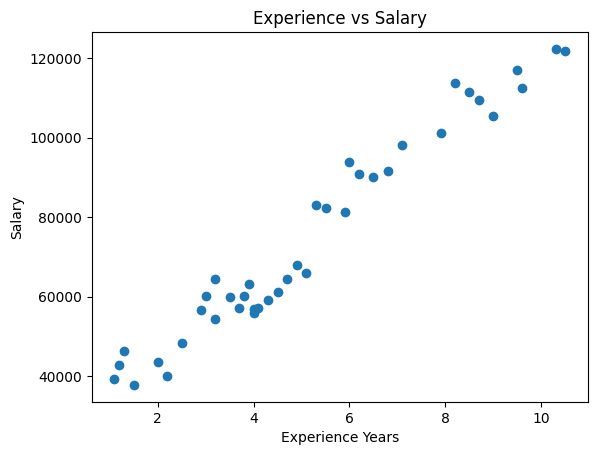

In [8]:
#Scatter Plot
import matplotlib.pyplot as plt
plt.scatter(X, y)
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.title('Experience vs Salary')
plt.show()

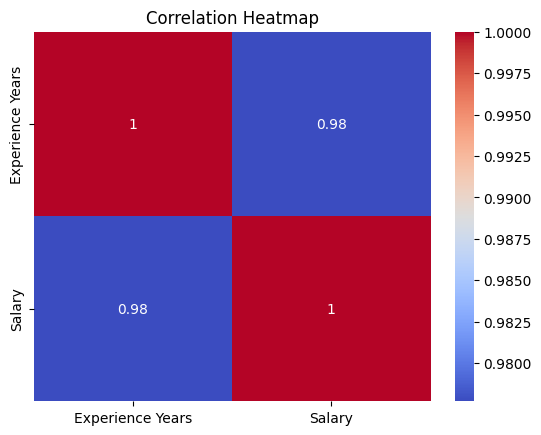

In [9]:
#Heatmap
import seaborn as sns
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [15]:
#Features and Labels
X = df['Experience Years'].values.reshape(-1, 1)
y = df['Salary'].values


In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
#Train Linear Regression
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
#Predict
y_pred = lin_model.predict(X_test)


In [19]:
#Evaluate
from sklearn.metrics import mean_squared_error, r2_score                
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 48077731.16919359
R^2 Score: 0.9068577573647874


In [20]:
#Train Decision Tree
from sklearn.tree import DecisionTreeRegressor
dt_model = DecisionTreeRegressor(random_state=42)   
dt_model.fit(X_train, y_train)
#Predict
y_dt_pred = dt_model.predict(X_test)


In [21]:
#Evaluate
dt_mse = mean_squared_error(y_test, y_dt_pred)
dt_r2 = r2_score(y_test, y_dt_pred)
print(f'Decision Tree Mean Squared Error: {dt_mse}')
print(f'Decision Tree R^2 Score: {dt_r2}')  

Decision Tree Mean Squared Error: 48811060.5
Decision Tree R^2 Score: 0.9054370593243345


In [22]:
#Train KNN
from sklearn.neighbors import KNeighborsRegressor
knn_model = KNeighborsRegressor(n_neighbors=3)
knn_model.fit(X_train, y_train)
#Predict
y_knn_pred = knn_model.predict(X_test)



In [23]:
#Evaluate
knn_mse = mean_squared_error(y_test, y_knn_pred)    
knn_r2 = r2_score(y_test, y_knn_pred)
print(f'KNN Mean Squared Error: {knn_mse}')
print(f'KNN R^2 Score: {knn_r2}')

KNN Mean Squared Error: 19169382.097222235
KNN R^2 Score: 0.9628626560562275


In [24]:
#Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')


Mean Squared Error: 48077731.16919359
R^2 Score: 0.9068577573647874


In [25]:
#Save Metrics JSON
import json
metrics = {
    'Linear Regression': {'MSE': mse, 'R2': r2},
    'Decision Tree': {'MSE': dt_mse, 'R2': dt_r2},
    'KNN': {'MSE': knn_mse, 'R2': knn_r2}
}
with open('model_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)
    
    print("Metrics saved to model_metrics.json")
    

Metrics saved to model_metrics.json


In [26]:
#5 Fold Cross Validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    lin_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:")
print(scores)

print("Average Score:", scores.mean())


Cross Validation Scores:
[ 0.15031087 -1.24990374 -0.01020364  0.12442657  0.14448258]
Average Score: -0.16817747092303958


In [27]:
new_data = np.array([[2.5], [5.0], [8.0]])

predictions = lin_model.predict(new_data)

print(predictions)

[ 50236.32835741  73756.40653868 101980.5003562 ]


In [28]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV


params = {
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(),
    params,
    cv=5
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)


Best Parameters:
{'max_depth': 4, 'min_samples_split': 2}


In [29]:
#save model
import joblib       
joblib.dump(lin_model, 'linear_model.joblib')
print("Model saved as linear_model.joblib")

Model saved as linear_model.joblib


In [30]:
#Load Model
lin_model = joblib.load('linear_model.joblib')
print("end=> Model loaded successfully")

end=> Model loaded successfully


In [9]:
X_train = X_train.values.reshape(-1,1)
X_test = X_test.values.reshape(-1,1)


In [3]:
import numpy as np 
import pandas as pd
import sklearn
import streamlit as st 

print(np.__version__)
print(pd.__version__)
print(sklearn.__version__)
print(st.__version__)


2.3.2
2.3.2
1.7.2
1.49.1
